In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

#### Starting code

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (3/5)/((n_embd * block_size)**0.5) #* 0.2 # to skwash activations
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # to skwash activations
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # to avoide extreem valued at initialization
b2 = torch.randn(vocab_size,                      generator=g) * 0    # set biases to zero to not to make logits extreem

bngain = torch.ones(1, n_hidden)
bnbias = torch.zeros(1, n_hidden)
bnmean_running = torch.zeros(1, n_hidden) # to track mean and std of batches during training
bnstd_running = torch.ones(1, n_hidden)

parameters = [C, W1, W2, b2, bngain, bnbias] #b1,
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # Forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    
    # Linear layer
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    
    # BatchNorm Layer: normalizing & applying scale and shift:
    #----------------------------------------------------------------------
    # When a BatchNorm layer is added to a layer; having a bias for that layer is pointess
    # Because, firstly; when the mean is deducted from the preactivation in normalizing process, Automatically the
    # bias would be deducted as well. Secondly, the normalization in BatchNorm layer has the bias itself
    # that can preform as the layer bias. So b1 can be ignored. 
    bnmeani = hpreact.mean(0, keepdims = True)
    bnstdi = hpreact.std(0, keepdims = True)
    hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias 
    with torch.no_grad():
        # Exponential Moving Average
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdims = True))/hpreact.std(0, keepdims = True) + bnbias 
    #--------------------------------------------------------------------------------------
    
    # Non Linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0948
  20000/ 200000: 2.5804
  30000/ 200000: 1.9907
  40000/ 200000: 2.2723
  50000/ 200000: 1.7695
  60000/ 200000: 2.1102
  70000/ 200000: 2.3473
  80000/ 200000: 2.3416
  90000/ 200000: 2.0243
 100000/ 200000: 2.3454
 110000/ 200000: 2.4127
 120000/ 200000: 1.6720
 130000/ 200000: 1.9051
 140000/ 200000: 2.1920
 150000/ 200000: 1.9947
 160000/ 200000: 2.0602
 170000/ 200000: 2.4455
 180000/ 200000: 2.0516
 190000/ 200000: 2.0862


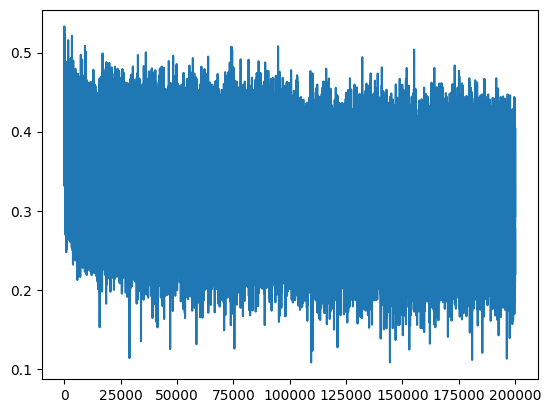

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 # + b1
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0590779781341553
val 2.104423761367798


#### Analysis on changes made on starting code

In [10]:
# Original losses:
    # train 2.1280276775360107
    # val 2.1642096042633057
    
# after modifying w2 and b2 to avoid making logits having extreem values that causes unstable 
# probability distribution after softmax which leads to higher loss:
    # train 2.069589138031006
    # val 2.1310744285583496
    
# after fix tanh layer too saturated init
    # train 2.0355966091156006
    # val 2.1026782989501953
    
# after adding a batch norm Layer    
    # train 2.0591280460357666
    # val 2.104520320892334

##### Analysis on initializing of hidden layer

In [11]:
# ================== Analysis on initializing in non-linearity part (hidden layer) ============

# In hidden layer when we have nonlinear activation functions that have flat tails-like sigmoid, tanh, relu
# ,and others; when pre-activation values from  embcat @ W1  + b1 fall in that region, in backpropagation
# the gradient of activation on that part would be zero so practically gradients of previous steps
# cannot pass from that neuron as according chain rule the the multiplication of previous gradiant by 
# local gradient becomes zero. meaning that neuron cannot be learned (weights and biases would not be updated)

# for example here that we have tanh, if embcat @ W1  + b1 becomes very high or low 
# the output of tanh(embcat @ W1  + b1) becomes -1 or 1. and according to derivative of tanh which is (1-t**2)
# the local gradient becomes zero. makes vanishing gradient.

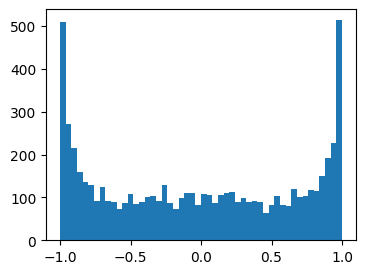

In [12]:
# According above, lets examine h
plt.figure(figsize=(4,3))
plt.hist(h.view(-1).tolist(), bins = 50)
plt.show()
# It is clear that there are lots of samples that after activation function results in -1 and 1

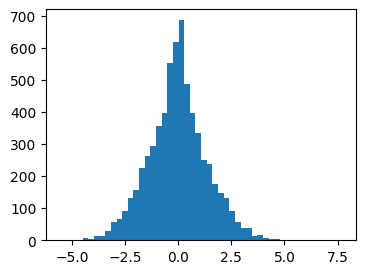

In [13]:
# According above, lets check pre-activation hpreact
plt.figure(figsize=(4,3))
plt.hist(hpreact.view(-1).tolist(), bins = 50)
plt.show()
# it is clear that pre-activation lies in a wide range

In [14]:
# this phenomena should be avoided to make the training process more efficient. because this could lead to
# non-updating of weights and biases of neurons with some samples. there even might be situations that all 
# samples result in very high or low preactivation values for some certain neurons leads to 
# non-updating of weights and biases of them; makes them dead neurons.

In [15]:
# It is worth mentioning that sometimes this can happen if we choose high learning rate in optimization 
# process as well. By inappropriate updating it may cause some neurons die because of high or low value
# of preactivation

##### calculating the init scale: “Kaiming init”

In [ ]:
# since "C" is initiatad to have normal distribution and embcat is concatenated of "C" sliced by Xb
# in embcat @ w1; what do we multiply w1 by to preserve standard deviation to be 1?
# The correct answer is mathematically: devide w1 to the square root of the fan_in(input dimention). here--> 30**0.5

# a paper by Kaiming is often refrenced for weight initializing. "Delving Deep into Rectifiers" by Kaiming He.

# This initialization also implemented in pytorch: torch.nn.init  ==> torch.nn.init.kaiming_normal()
# In this page you can find the formula to use initialization --> gain / square root of fan_in.
# gain is slightly different for different nonliniarity --> can be found on the top of torch.nn.init page.
# for example for tanh it is : 3/5

In [17]:
# Nowadays, modern inovations made everything more stable and it is become less important to initialize
# these network, exactly right. some of these inovations are for example:
    # residuals connections
    # use of normalization layers like:
            # batch normalization
            # layer normalization
            # group normalization
    # better optimizers:
            #ARS Prop
            # Adam
            
# But generally you can initialize weights by square root of fan_in.             

##### Batch normalization

In [18]:
# Paper: Batch Normalization by google
# Since we want preactivations be not to big and not to small so they are not be saturated in nonlinearity
# activation function; why not just normalize them before feeding them to nonlinearity(tanh).
# The normalization is done on each batch over features/columns. And the normalization method is differentiable

In [19]:
# But we want this normalization be done in initialization and we do not want these be forced to be 
# Gausian always. we would like to allow the neural net to move this around to potentially make it more diffuse
# to make it more sharp, to make some tanh neurons be more trigger happy or less trigger happy. We want 
# this distribution to move around and the backpropagation tell us how they should move around. 

In [20]:
# So in addition to the idea of standardizing activations; so we have to introduce a component in the paper
# called "scale and shift":
# we are getting the normalize input, scale them by some gain and offsetting them by some bias

In [21]:
# The stability offered by batch normalization comes at a cost:

# Before having batch normalization ==> for a single input the process was a determinestic process. Meaning
# a single example is being feeding to the network and the we calculate its activation and its logits.
# And for efficiency we started using batches of examples, but those batches of example were processed independently
# and it was just for efficiency. 

# BUt now in batch normalization ==> we are coupling these examples mathematically. now the hidden state 
# activation, hpreact, in the logits for any one example are not only a function of that example but also 
# they are function of other examples. It means logits of an example can change according to examples 
# that exist on that batch, because of change in mean and variance of the batch.

# However, in a strange way this turns out to be good in training a neural network. Because you can think of it 
# as regularizer, that make it harder for the neural net to over fit these examples by introducing this noise

# Although, no one likes this property of batch normalization that examples are coupled mathematically and
# people tried to move to other normalization techniques that not couple the examples of a batch like:
    # layer normalization
    # instance normalization
    # group normalization
# it has been hard to remove it because it works quite well    

In [22]:
# We are using batch normalization to control the statistics of activations in the neural net. It is common
# to sprinkle batch normalization layer accross the neural net. Usually we place it after layers that 
# have multiplication, like a linear layer or convolutional layer

#### Torchify Version

In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator = g)/(fan_in**0.5) # initiate weight tensor by using standard normal distribution & Kaiming init method
        self.bias = torch.zeros(fan_out) if bias else None # initiate bias; should be false if a batchnorm is applied on top of the linear layer
            
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm:
    
    def __init__(self, dim, eps=1e-05, momentum=0.1):
        self.eps = eps # use in normalization denominator to avoid devided by zero
        self.momentum = momentum #using to calculate buffers by exponential moving average technique
        self.training = True
        # parameters(trained with backpropagation)
        self.gama = torch.ones(dim) # the gain for scaling. according the paper
        self.beta = torch.zeros(dim) # the bias for shifting
        # buffers (trained with a running momentum update in training process) 
        self.bnmean_running = torch.zeros(dim)
        self.bnvar_running = torch.ones(dim)
        
    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar = x.var(0, keepdim = True) # batch variance
        else:
            xmean = self.bnmean_running  # Use trained buffers in non-training cases
            xvar = self.bnvar_running
        # normalize mini batches and applying scaling and shifting
        xhat = (x-xmean) / torch.sqrt(xvar + self.eps)
        self.out =  self.gama * xhat +  self.beta
        
        # updating buffers during training process
        if self.training:
            with torch.no_grad(): # we do not want torch keep track of all created tensors during training as we do not apply backpropagation on it
                self.bnmean_running = (1- self.momentum) * self.bnmean_running + self.momentum * xmean
                self.bnvar_running = (1- self.momentum) * self.bnvar_running + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gama, self.beta]
    
        
        
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

##### Before BatchNorm

In [24]:
# initiate the MLP network
n_embed = 10 # the dimensionality of character embedding vectors
n_hidden = 100 # the number of neurons in each linear layer of MLP
block_size = 3
g = torch.Generator().manual_seed(2147483647) # initiate generator for reproducibility

C = torch.randn((vocab_size, n_embed), generator = g) # Create embeddings

layers = [Linear(n_embed * block_size, n_hidden), Tanh(),
          Linear(n_hidden, n_hidden), Tanh(),
          Linear(n_hidden, n_hidden), Tanh(),
          Linear(n_hidden, n_hidden), Tanh(),
          Linear(n_hidden, n_hidden), Tanh(),
          Linear(n_hidden, vocab_size)
        ]

with torch.no_grad():
    layers[-1].weight *= 0.01 # make last layer less extreem
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # 0.5 #1  # since the nonlinearity is tanh, the gain in Kaiming is 3/5

parameters =  [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

46497


In [ ]:
# Optimizing
batch_size = 32
steps = 200000
lossi = []
ud = []

for i in range(steps):
    # create mini_batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, yb = Xtr[ix], Ytr[ix] 

    # forward path
    emb = C[Xb]  # (batch_size, block_size, n_embed)
    x = emb.view(emb.shape[0], -1) # (batch_size, block_size * n_embed)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    # backward path
    for layer in layers:
        layer.out.retain_grad()  # to retain intermediat gradiant in backward path. here layer's out gradients 
    
    for p in parameters:
        p.grad = None
    loss.backward()   

    # Updating
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad 

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
    
    lossi.append(loss.log10().item())  
    if i > 1000:
        break
      

      0/ 200000: 3.2970


layer 1 (      Tanh): mean -0.04, std 0.77, saturated: 22.12%
layer 3 (      Tanh): mean -0.01, std 0.72, saturated: 12.09%
layer 5 (      Tanh): mean +0.00, std 0.75, saturated: 14.25%
layer 7 (      Tanh): mean -0.03, std 0.73, saturated: 12.16%
layer 9 (      Tanh): mean -0.01, std 0.72, saturated: 10.72%


Text(0.5, 1.0, 'activation distribution')

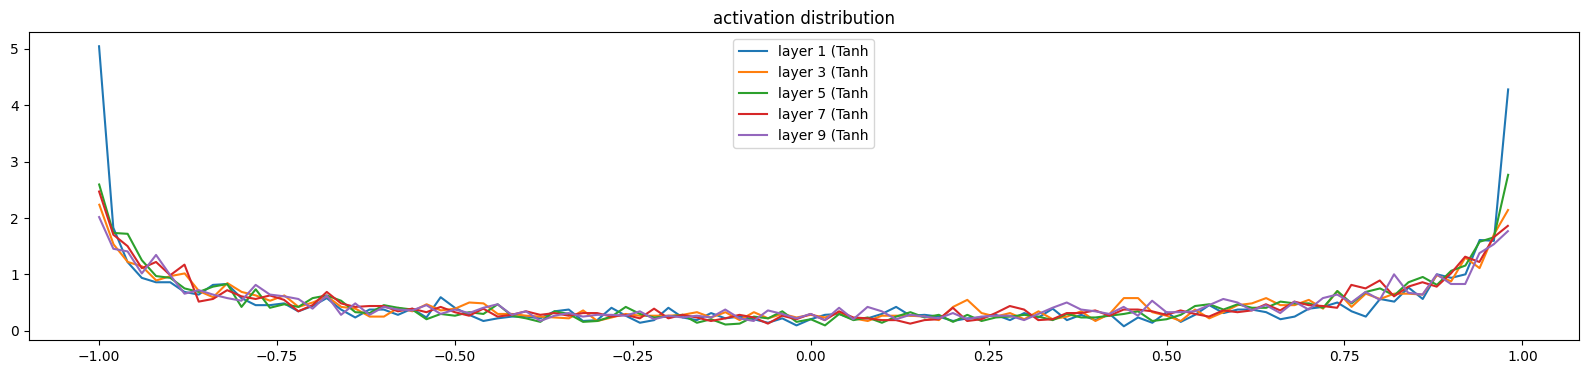

In [26]:
#visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

In [ ]:
# Looking at activation distribution
# We are looking at how many values in these tensors have any of the values between 1 and -1
# the first layer is fairly saturated(20%) and every thing is stabilizes. comes to std 
# of 0.66 and saturation of 6.16%. The reason of these nice distribution is because gain 
# is set to 5/3.

# if we set it to 1 (or 0.5). the more we go through the layers, further layers are shrinking to zero.
# and it is not desirable. because we want to have more uniform distribution. When activations tend to shrink 
# as they pass through each layer, it is undesirable because it reduces the effectiveness of the network in learning.
# shrinking to zero means that the more we go through layers the more they become
# useless in backpropagation(according to the derivative of tanh). 
## Reminder: saturated values of tanh kills the neuron( make gradient equals
## to zero) and values close to zero make the layer useless(just pass previous
## gradient and do not contribute in training). dtanh(x)/dx = 1-x**2

# and this happens because tanh is like a shrinking function and the more layers
# are stacked the more the output would shrink. So we need some gain to fight 
# this shrinking. and it turns out that 5/3 is a good gain.

layer 1 (      Tanh): mean -0.000005, std 2.853988e-03
layer 3 (      Tanh): mean -0.000067, std 2.827549e-03
layer 5 (      Tanh): mean +0.000052, std 2.806120e-03
layer 7 (      Tanh): mean -0.000052, std 2.766865e-03
layer 9 (      Tanh): mean +0.000014, std 2.252768e-03


Text(0.5, 1.0, 'gradient distribution')

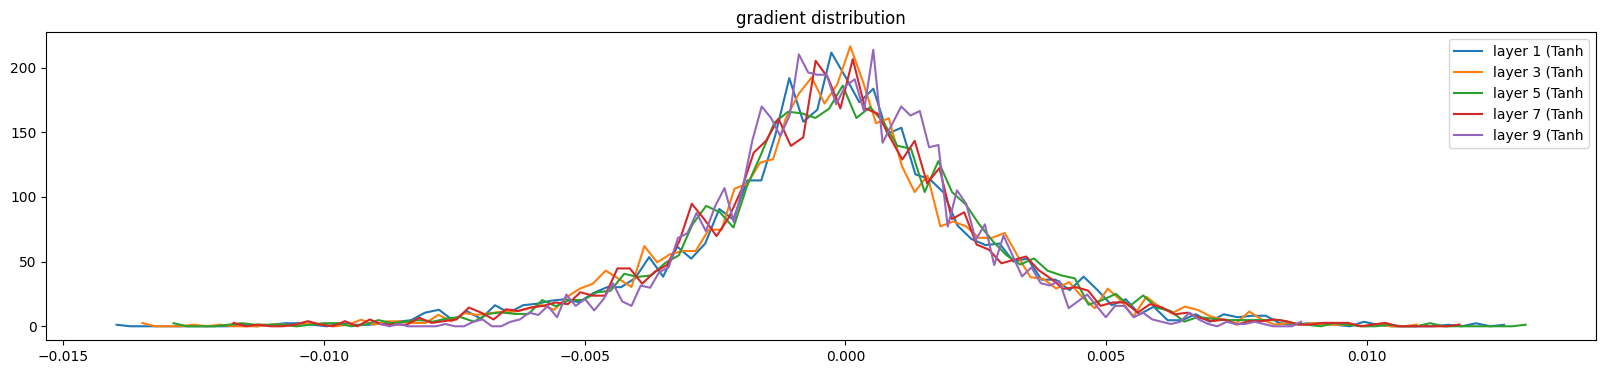

In [28]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

In [29]:
# Looking to the gradients distribution on different layers
# it can be seen that every layer in this sandwich has roughly the same gradient
# things are not shrinking or exploding. and this is desireable because it showes that layers are contributing
# roughly the same in training process.

# but if we reduce the gain(saying 0.5) in early/first layers gradiants are shrinked and then they are expanding in
# higher layers. meaning in backpropogation the gradients of first layers tend to vanish.

In [30]:
#Above shows that how much was important the initializing of weights before introducing techniques like
#BachNormalizations, residual connections, and optimizing methods like Adam

weight   (27, 10) | mean -0.000933 | std 1.121138e-02 | grad:data ratio 1.121041e-02
weight  (30, 100) | mean -0.000067 | std 9.281265e-03 | grad:data ratio 2.967279e-02
weight (100, 100) | mean +0.000061 | std 7.151001e-03 | grad:data ratio 4.253223e-02
weight (100, 100) | mean -0.000214 | std 6.442997e-03 | grad:data ratio 3.798574e-02
weight (100, 100) | mean -0.000070 | std 6.095318e-03 | grad:data ratio 3.613813e-02
weight (100, 100) | mean +0.000013 | std 5.058823e-03 | grad:data ratio 3.005517e-02
weight  (100, 27) | mean -0.000000 | std 1.990044e-02 | grad:data ratio 2.862427e-01


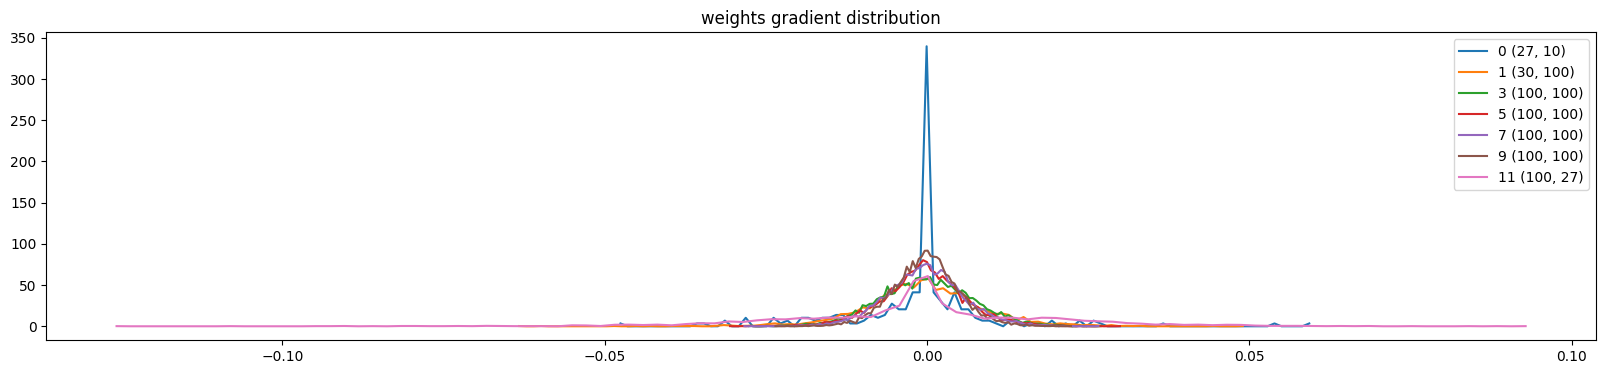

In [31]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters): # when p is used; it equals to p.data
    t = p.grad
    if p.ndim == 2: # Just picking gradients of linear layers and the embeddings
        # use std statistics for grad:data
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [32]:
# In weight gradient distribution:
# this plot is important, because we are updating parameters, so we care about their gradients and their values. 
# we also can see the scale of gradient to the scale of data actual values. According to this metric it is clear that
# the last layer is trouble maker.the last layer contributes alot and has higher gradient values compare to inner layers
# and you train this layer faster than other layers **at initialization**

In [33]:
# If we train a little bit longer it starts to shrink more.

In [34]:
# The ratio of gradient to data is not informative enough. what matters at the end is not gradient to data
# but **update to data** ratio. because it is the amount that we change in data.
# so in tracking section of code we introduce a metric for this: ud = []

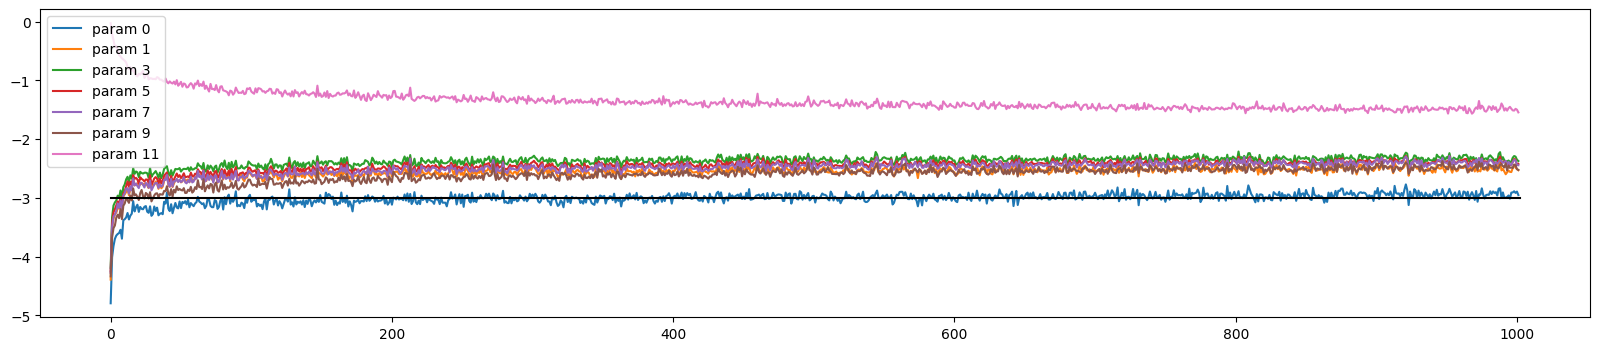

In [35]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [36]:
# Now we plot update ratios and see they evolve during time during initialization. it can be seen that they are
# stabelizing
# an approximated value as a balck line also ploted that is a rough gide that what should this ratio be.
#meaning the update in every iteration should not be more than 1000th of magnitud of values in the tensor.

# when it is below -3(in log10 scale) it means it is not training fast enough. and being very high above -3
# means it updates to fast.
# the ratio for param 11 is very high because in initialization we artificially made weights small(by multiplying by 0.1)


##### implement BatchNorm

In [37]:
# initiate the MLP network
n_embed = 10 # the dimensionality of character embedding vectors
n_hidden = 100 # the number of neurons in each linear layer of MLP
block_size = 3
g = torch.Generator().manual_seed(2147483647) # initiate generator for reproducibility

C = torch.randn((vocab_size, n_embed), generator = g) # Create embeddings

layers = [Linear(n_embed * block_size, n_hidden, bias = False), BatchNorm(n_hidden),Tanh(),
          Linear(n_hidden, n_hidden,  bias = False),            BatchNorm(n_hidden), Tanh(),
          Linear(n_hidden, n_hidden,  bias = False),            BatchNorm(n_hidden), Tanh(),
          Linear(n_hidden, n_hidden,  bias = False),            BatchNorm(n_hidden), Tanh(),
          Linear(n_hidden, n_hidden,  bias = False),            BatchNorm(n_hidden), Tanh(),
          Linear(n_hidden, vocab_size, bias = False),           BatchNorm(vocab_size)
        ]

with torch.no_grad():
    layers[-1].gama *= 0.01 
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1 # set gain equal to 1 instead of 5/3 

parameters =  [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47024


In [38]:
# Optimizing
batch_size = 32
steps = 200000
lossi = []
ud = []

for i in range(steps):
    # create mini_batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, yb = Xtr[ix], Ytr[ix] 

    # forward path
    emb = C[Xb]  # (batch_size, block_size, n_embed)
    x = emb.view(emb.shape[0], -1) # (batch_size, block_size * n_embed)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    # backward path
    for layer in layers:
        layer.out.retain_grad()  # to retain intermediat gradiant in backward path. here layer's out gradients 
    for p in parameters:
        p.grad = None
    loss.backward()   

    # Updating
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad 

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
    
    lossi.append(loss.log10().item())  
    if i > 1000:
        break
      

      0/ 200000: 3.2936


layer 2 (      Tanh): mean -0.01, std 0.63, saturated: 2.91%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 3.03%
layer 8 (      Tanh): mean -0.01, std 0.64, saturated: 2.69%
layer 11 (      Tanh): mean -0.00, std 0.66, saturated: 1.94%
layer 14 (      Tanh): mean +0.00, std 0.66, saturated: 1.47%


Text(0.5, 1.0, 'activation distribution')

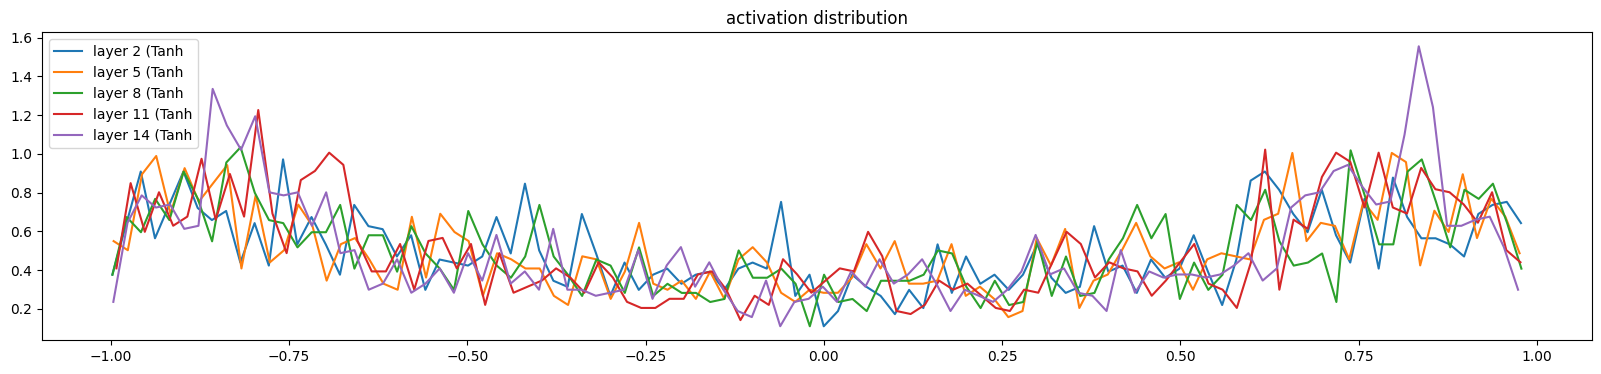

In [39]:
#visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 2.952569e-03
layer 5 (      Tanh): mean +0.000000, std 2.406134e-03
layer 8 (      Tanh): mean -0.000000, std 2.124936e-03
layer 11 (      Tanh): mean -0.000000, std 1.990848e-03
layer 14 (      Tanh): mean +0.000000, std 2.006852e-03


Text(0.5, 1.0, 'gradient distribution')

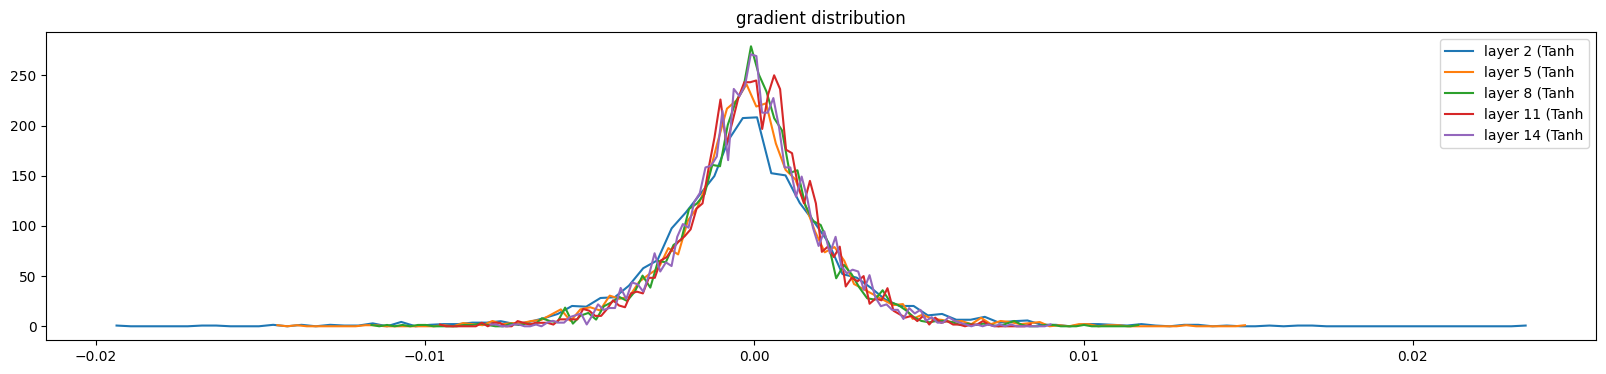

In [40]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 8.090096e-03 | grad:data ratio 8.082405e-03
weight  (30, 100) | mean +0.000094 | std 1.114072e-02 | grad:data ratio 5.891649e-02
weight (100, 100) | mean +0.000012 | std 8.453018e-03 | grad:data ratio 8.281258e-02
weight (100, 100) | mean -0.000044 | std 7.082215e-03 | grad:data ratio 6.920129e-02
weight (100, 100) | mean -0.000044 | std 6.249762e-03 | grad:data ratio 6.150141e-02
weight (100, 100) | mean -0.000016 | std 5.754089e-03 | grad:data ratio 5.667141e-02
weight  (100, 27) | mean -0.000198 | std 1.223203e-02 | grad:data ratio 1.185894e-01


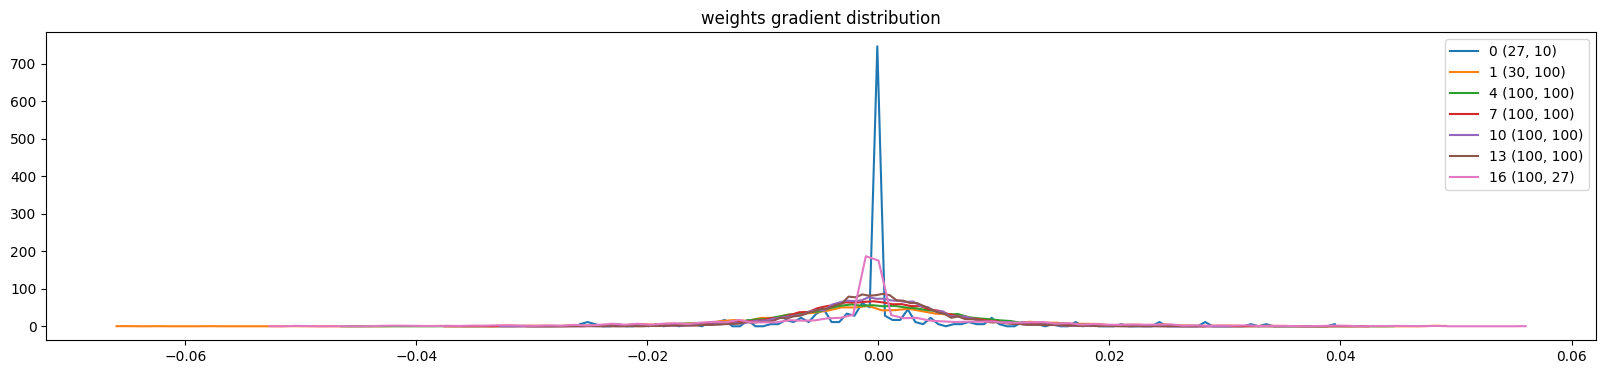

In [41]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters): # when p is used; it equals to p.data
    t = p.grad
    if p.ndim == 2: # Just picking gradients of linear layers and the embeddings
        # use std statistics for grad:data
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

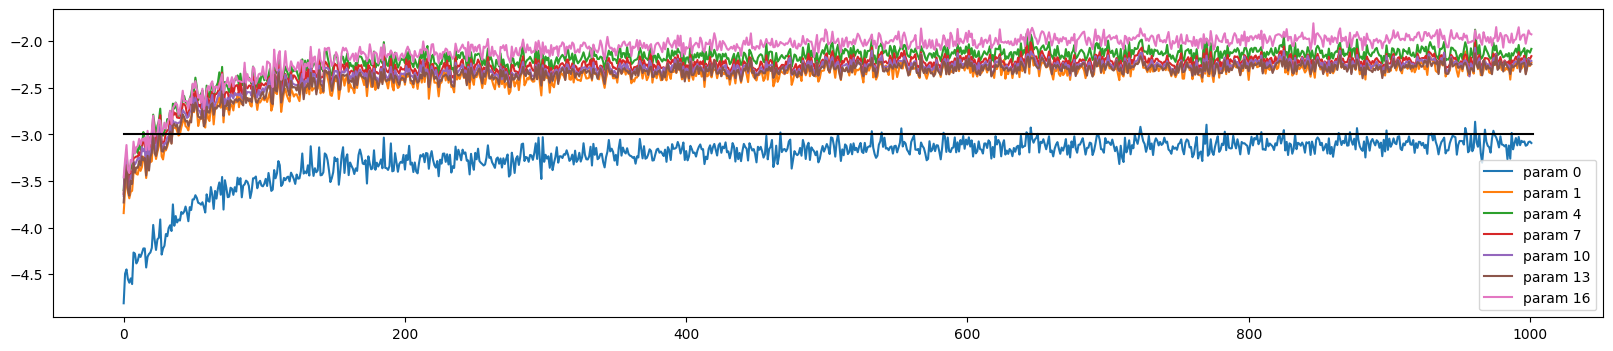

In [42]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [44]:
# by using batchnorm, even with setting gain to 1 the result is good.

# even if in linear layer definition we forget to use (fan_in**0.5) in weight initiatian and just initialize 
# weight by random normal distribution the result would be good except the update ratio would be high that 
# should be delt with.